# Лабораторная работа №5  
## Нейронные сети. Многослойный перцептрон MLP

**Задание:** «Выборы президента».

**Цель:** разработать и обучить нейросеть, которая предсказывает победу на выборах по ответам избирателей на 12 вопросов.

В работе будет сделано:
1. Подготовка данных.
2. Создание MLP с одним скрытым слоем.
3. Использование функции активации `logsig`.
4. Обучение модели.
5. Проверка точности.
6. Визуализация результатов.

## 1. Импорт библиотек

Используем только простые библиотеки:

- `numpy` — для вычислений;
- `matplotlib` — для графиков.

TensorFlow и Keras не используем, чтобы работа была проще и понятнее.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Создание данных

По заданию:

- `dataIn.txt` — матрица размера **12 × N**, где 12 — количество вопросов, N — количество примеров;
- `dataOut.txt` — матрица размера **2 × N**, где:
  - `[1, 0]` — победа правящей партии;
  - `[0, 1]` — победа оппозиции.

Сгенерируем 100 примеров.  
Ответы на вопросы будут бинарными: `0` или `1`.

Чтобы данные были логичными, зададим простое правило:

- если сумма ответов избирателя больше или равна 6 — побеждает правящая партия;
- иначе побеждает оппозиция.

In [14]:
np.random.seed(42)

N = 100              # количество примеров
num_questions = 12   # количество вопросов

# X_file имеет размер 12 x N, как указано в задании
X_file = np.random.randint(0, 2, size=(num_questions, N))

# Сумма ответов по каждому избирателю
answers_sum = X_file.sum(axis=0)

# Создаем Y_file размера 2 x N
Y_file = np.zeros((2, N), dtype=int)

# Если сумма ответов >= 6, то [1, 0], иначе [0, 1]
Y_file[0, answers_sum >= 6] = 1
Y_file[1, answers_sum < 6] = 1

# Сохраняем данные в файлы
np.savetxt('dataIn.txt', X_file, fmt='%d')
np.savetxt('dataOut.txt', Y_file, fmt='%d')

print('Файлы dataIn.txt и dataOut.txt созданы')
print('Размер dataIn.txt:', X_file.shape)
print('Размер dataOut.txt:', Y_file.shape)

Файлы dataIn.txt и dataOut.txt созданы
Размер dataIn.txt: (12, 100)
Размер dataOut.txt: (2, 100)


## 3. Загрузка данных из файлов

Загружаем данные из файлов.

Для обучения удобнее, чтобы строки были примерами, а столбцы — признаками.  
Поэтому после загрузки транспонируем матрицы:

- `X`: размер **N × 12**;
- `Y`: размер **N × 2**.

In [15]:
X_loaded = np.loadtxt('dataIn.txt', dtype=float)
Y_loaded = np.loadtxt('dataOut.txt', dtype=float)

# Транспонируем данные для удобного обучения
X = X_loaded.T
Y = Y_loaded.T

print('Размер X после транспонирования:', X.shape)
print('Размер Y после транспонирования:', Y.shape)

print('\nПервые 5 строк X:')
print(X[:5])

print('\nПервые 5 строк Y:')
print(Y[:5])

Размер X после транспонирования: (100, 12)
Размер Y после транспонирования: (100, 2)

Первые 5 строк X:
[[0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0.]
 [1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 1.]
 [0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0.]
 [0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1.]]

Первые 5 строк Y:
[[0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]]


## 4. Разделение на обучающую и тестовую выборки

Разделим данные:

- 80% — для обучения;
- 20% — для тестирования.

Обучающая выборка нужна для настройки весов нейросети.  
Тестовая выборка нужна для проверки качества модели на новых данных.

In [16]:
indices = np.arange(N)
np.random.shuffle(indices)

train_size = int(0.8 * N)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
Y_train = Y[train_indices]

X_test = X[test_indices]
Y_test = Y[test_indices]

print('Размер обучающей выборки:', X_train.shape)
print('Размер тестовой выборки:', X_test.shape)

Размер обучающей выборки: (80, 12)
Размер тестовой выборки: (20, 12)


## 5. Функция активации logsig

По заданию нужна функция активации `logsig`.

Она задается формулой:

$$
logsig(x) = \frac{1}{1 + e^{-x}}
$$

Эта функция возвращает значения от 0 до 1.

In [17]:
def logsig(x):
    return 1 / (1 + np.exp(-x))


def logsig_derivative(y):
    # Производная logsig через уже посчитанное значение y = logsig(x)
    return y * (1 - y)

## 6. Создание нейросети MLP

Создаем многослойный перцептрон с одним скрытым слоем.

Архитектура:

- входной слой: 12 нейронов;
- скрытый слой: 8 нейронов;
- выходной слой: 2 нейрона.

Выходные 2 нейрона соответствуют двум классам:

- 0 — победа правящей партии;
- 1 — победа оппозиции.

In [18]:
input_neurons = 12
hidden_neurons = 8
output_neurons = 2

np.random.seed(42)

# Веса от входного слоя к скрытому
W1 = np.random.randn(input_neurons, hidden_neurons) * 0.1
b1 = np.zeros((1, hidden_neurons))

# Веса от скрытого слоя к выходному
W2 = np.random.randn(hidden_neurons, output_neurons) * 0.1
b2 = np.zeros((1, output_neurons))

print('Нейросеть создана')
print('W1:', W1.shape)
print('W2:', W2.shape)

Нейросеть создана
W1: (12, 8)
W2: (8, 2)


## 7. Обучение нейросети

Обучение состоит из двух этапов:

1. **Прямой проход** — нейросеть делает предсказание.
2. **Обратное распространение ошибки** — веса изменяются так, чтобы ошибка уменьшалась.

Будем использовать простую ошибку MSE:

$$
MSE = \frac{1}{n}\sum (y - \hat{y})^2
$$

In [19]:
learning_rate = 0.5
epochs = 3000

loss_history = []

for epoch in range(epochs):
    # Прямой проход
    hidden_input = X_train @ W1 + b1
    hidden_output = logsig(hidden_input)

    final_input = hidden_output @ W2 + b2
    final_output = logsig(final_input)

    # Ошибка
    error = Y_train - final_output
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # Обратное распространение ошибки
    d_output = error * logsig_derivative(final_output)

    error_hidden = d_output @ W2.T
    d_hidden = error_hidden * logsig_derivative(hidden_output)

    # Обновление весов
    W2 += learning_rate * hidden_output.T @ d_output / len(X_train)
    b2 += learning_rate * np.mean(d_output, axis=0, keepdims=True)

    W1 += learning_rate * X_train.T @ d_hidden / len(X_train)
    b1 += learning_rate * np.mean(d_hidden, axis=0, keepdims=True)

    if (epoch + 1) % 500 == 0:
        print('Эпоха:', epoch + 1, 'Ошибка:', round(loss, 4))

Эпоха: 500 Ошибка: 0.1608
Эпоха: 1000 Ошибка: 0.0697
Эпоха: 1500 Ошибка: 0.0345
Эпоха: 2000 Ошибка: 0.0209
Эпоха: 2500 Ошибка: 0.0144
Эпоха: 3000 Ошибка: 0.0107


## 8. График ошибки обучения

Построим график ошибки.  
Если ошибка уменьшается, значит нейросеть обучается.

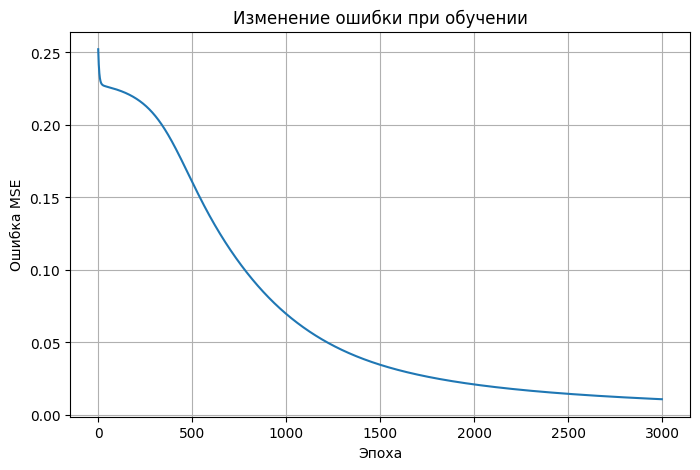

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel('Эпоха')
plt.ylabel('Ошибка MSE')
plt.title('Изменение ошибки при обучении')
plt.grid(True)
plt.show()

## 9. Проверка точности модели

Проверим модель на обучающей и тестовой выборках.

Для выбора класса берем нейрон с наибольшим выходным значением.

In [21]:
def predict(X_data):
    hidden = logsig(X_data @ W1 + b1)
    output = logsig(hidden @ W2 + b2)
    return np.argmax(output, axis=1), output


train_pred, train_output = predict(X_train)
test_pred, test_output = predict(X_test)

train_true = np.argmax(Y_train, axis=1)
test_true = np.argmax(Y_test, axis=1)

train_accuracy = np.mean(train_pred == train_true)
test_accuracy = np.mean(test_pred == test_true)

print('Точность на обучающей выборке:', round(train_accuracy, 3))
print('Точность на тестовой выборке:', round(test_accuracy, 3))

Точность на обучающей выборке: 1.0
Точность на тестовой выборке: 0.85


## 10. Визуализация результатов

Построим график, где сравним настоящие классы и предсказанные классы на тестовой выборке.

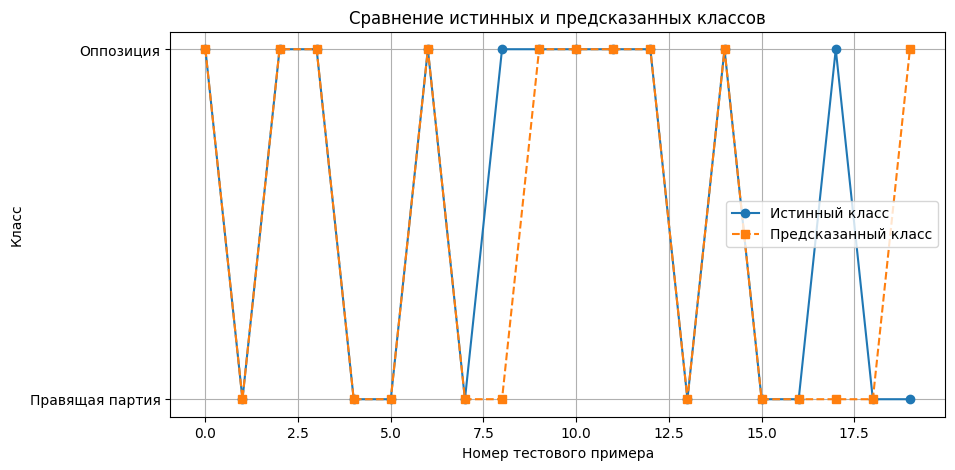

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(test_true, 'o-', label='Истинный класс')
plt.plot(test_pred, 's--', label='Предсказанный класс')

plt.xlabel('Номер тестового примера')
plt.ylabel('Класс')
plt.title('Сравнение истинных и предсказанных классов')
plt.yticks([0, 1], ['Правящая партия', 'Оппозиция'])
plt.legend()
plt.grid(True)
plt.show()

## 11. Проверка на новом избирателе

Проверим модель на новом примере.

Новый избиратель ответил на 12 вопросов.  
Каждый ответ равен `0` или `1`.

In [23]:
new_voter = np.array([[1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1]])

new_pred, new_output = predict(new_voter)

print('Ответы нового избирателя:')
print(new_voter)

print('\nВыходы нейросети:')
print(new_output)

if new_pred[0] == 0:
    print('\nПрогноз: победит правящая партия')
else:
    print('\nПрогноз: победит оппозиция')

Ответы нового избирателя:
[[1 1 0 1 0 1 1 0 1 0 1 1]]

Выходы нейросети:
[[0.99615217 0.00384436]]

Прогноз: победит правящая партия


## 12. Вывод

В ходе лабораторной работы была создана простая нейронная сеть MLP.

Было выполнено:

1. Созданы и сохранены данные `dataIn.txt` и `dataOut.txt`.
2. Данные были загружены и подготовлены.
3. Создан многослойный перцептрон с одним скрытым слоем.
4. Использована функция активации `logsig`.
5. Модель была обучена методом обратного распространения ошибки.
6. Была рассчитана точность модели.
7. Были построены графики ошибки и предсказаний.

Нейросеть научилась предсказывать один из двух исходов выборов на основе 12 ответов избирателя.